# **Sparse DICTIONARY LEARNING: Matheo Madrid** #

### **Importamos librerias que vamos a utilizar:**

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import seaborn as sns 

from datetime import datetime
from meteostat import Point, Daily
from sklearn.decomposition import DictionaryLearning
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

### **Extraemos los datos metereológicos:**

In [ ]:
print("Conectando a bases de datos globales (NOAA/OMM)...")

ubicacion = Point(40.4168, -3.7038, 667)

inicio = datetime(1990, 1, 1)
fin = datetime(2023, 12, 31)

datos_brutos = Daily(ubicacion, inicio, fin).fetch()

print(f"Datos crudos descargados: {datos_brutos.shape[0]} días.")

Conectando a bases de datos globales (NOAA/OMM)...
Datos crudos descargados: 12418 días.


### **Preparamos las series temporales:**

#### Inspección de Valores Nulos (NaN)

Antes de transformar o rellenar nuestra serie temporal, es fundamental saber la calidad de los datos crudos y comprobar si existen valores faltantes (`NaN`).

**¿Por qué es crítico este paso?**
El algoritmo del **Sparse Coding** (al igual que la gran mayoría de técnicas de *Machine Learning*) requiere matrices puramente numéricas para funcionar. Su aprendizaje se basa en operaciones complejas de álgebra lineal; por tanto, la presencia de un solo valor `NaN` (Not a Number) en los 34 años de registros rompería los cálculos matemáticos y haría que el modelo fallara inmediatamente.

A continuación, vamos a contabilizar exactamente cuántos días carecen de mediciones y en qué variables físicas ocurren. Esto nos permitirá decidir si es seguro aplicar técnicas de relleno (como la interpolación, o tomar el mismo valor del dia anterior o posterior) o si los huecos son tan grandes que requieren descartar ciertos periodos.

In [ ]:
print("Recuento de valores faltantes por columna:")
print(datos_brutos.isnull().sum())
print("-" * 60)

dias_con_nulos = datos_brutos[datos_brutos.isnull().any(axis=1)]

print(f"Total de días que tienen algún dato en blanco: {len(dias_con_nulos)} de {len(datos_brutos)}")

print("\nMuestra de los días con huecos:")
print(dias_con_nulos.head(20))
print("-" * 60)

Recuento de valores faltantes por columna:
tavg        1
tmin        0
tmax        0
prcp        3
snow    12396
wdir    12418
wspd     2486
wpgt    12418
pres     5960
tsun    12418
dtype: int64
------------------------------------------------------------
Total de días que tienen algún dato en blanco: 12418 de 12418

Muestra de los días con huecos:
            tavg  tmin  tmax  prcp  snow  wdir  wspd  wpgt  pres  tsun
time                                                                  
1990-01-01   7.3   6.9   8.3   6.5  <NA>  <NA>   3.0  <NA>  <NA>  <NA>
1990-01-02   5.4   5.5   7.3   5.0  <NA>  <NA>   5.5  <NA>  <NA>  <NA>
1990-01-03   7.5   4.8   8.9   0.7  <NA>  <NA>   4.4  <NA>  <NA>  <NA>
1990-01-04   7.0   2.4  10.4   0.0  <NA>  <NA>   2.9  <NA>  <NA>  <NA>
1990-01-05   7.0   3.3  10.3   0.0  <NA>  <NA>   2.6  <NA>  <NA>  <NA>
1990-01-06   5.2   2.5   8.4   0.0  <NA>  <NA>   1.2  <NA>  <NA>  <NA>
1990-01-07   7.6   5.3   9.9   0.0  <NA>  <NA>   8.4  <NA>  <NA>  <NA>
1990-01-0

In [ ]:
from pandarallel import pandarallel 

pandarallel.initialize(progress_bar=True)

columnas_utiles = ['tavg', 'tmin', 'tmax', 'prcp', 'wspd']

datos_limpios = datos_brutos[columnas_utiles].copy()

print("✅ Dataset filtrado correctamente.")
print("-" * 60)
print("Variables actuales:", datos_limpios.columns.tolist())
print("-" * 60)
print("Recuento de huecos a interpolar en el siguiente paso:")
print(datos_limpios.isnull().sum())

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.
✅ Dataset filtrado correctamente.
------------------------------------------------------------
Variables actuales: ['tavg', 'tmin', 'tmax', 'prcp', 'wspd']
------------------------------------------------------------
Recuento de huecos a interpolar en el siguiente paso:
tavg       1
tmin       0
tmax       0
prcp       3
wspd    2486
dtype: int64


#### Limpieza Preventiva y Preparación Matemática de la Serie Temporal

Aunque nuestra inspección previa nos haya revelado una matriz perfecta sin valores nulos, un código de *Machine Learning* robusto debe estar preparado para cualquier eventualidad. Si en el futuro cambiamos las coordenadas a una estación meteorológica menos constante, o si la base de datos de origen se actualiza con nuevos huecos, este bloque de código actuará como un mecanismo de seguridad automático.

Aquí aplicamos tres filtros de preprocesamiento fundamentales antes de inyectar los datos en el algoritmo:

1. **Filtro de fiabilidad (Umbral del 70%):** Si un sensor ha estado estropeado o inactivo más del 30% del tiempo durante estas tres décadas, eliminamos esa dimensión por completo para evitar que el modelo aprenda sobre "ruido" o datos artificiales.
2. **Imputación de valores faltantes (Relleno de huecos):** Para los días sueltos en los que un sensor pudo haber fallado, aplicamos técnicas de reconstrucción. Se puede optar por arrastrar el último valor válido conocido (`ffill`), o utilizar una **interpolación lineal**, que calcula matemáticamente el punto medio entre el día anterior y el posterior (ideal para variables climáticas continuas).
3. **Aislamiento de la matriz numérica:** El *Sparse Coding* requiere álgebra lineal pura. En este último paso, separamos exclusivamente las columnas métricas (aislándolas de fechas o metadatos) para construir la matriz final que procesará el modelo.

In [ ]:
pandarallel.initialize(progress_bar=False)

datos_limpios = datos_limpios.parallel_apply(
    lambda col: col.interpolate(method='linear').bfill().ffill()
)

X_raw = datos_limpios.select_dtypes(include=[np.number]) 
nombres_variables = X_raw.columns.tolist() 
dias_totales = X_raw.shape[0] 
dimension_real = X_raw.shape[1]

print("-" * 60)
print(f"Matriz consolidada: {dias_totales} días válidos con {dimension_real} dimensiones físicas.")
print("Variables incluidas:", nombres_variables)
print("-" * 60)

INFO: Pandarallel will run on 8 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.
------------------------------------------------------------
Matriz consolidada: 12418 días válidos con 5 dimensiones físicas.
Variables incluidas: ['tavg', 'tmin', 'tmax', 'prcp', 'wspd']
------------------------------------------------------------


### **Separamos el dataset en *training* y *test*:**

In [ ]:
corte = int(dias_totales * 0.70)  
X_train_raw = X_raw.iloc[:corte]  
X_test_raw = X_raw.iloc[corte:]

scaler = StandardScaler()  
X_train_scaled = scaler.fit_transform(X_train_raw) 
X_test_scaled = scaler.transform(X_test_raw)  

print(f"Días de Entrenamiento (Pasado histórico): {X_train_scaled.shape[0]}")
print(f"Días de Prueba (La última década):        {X_test_scaled.shape[0]}")
print("-" * 60)

Días de Entrenamiento (Pasado histórico): 8692
Días de Prueba (La última década):        3726
------------------------------------------------------------


### **Iniciamos el aprendizaje del diccionario:**

In [ ]:
n_atoms = 40

print(f"Entrenando {n_atoms} átomos históricos usando el pasado (Train)...")

dict_learner = DictionaryLearning(
    n_components=n_atoms, 
    alpha=0.5, 
    transform_algorithm='lasso_lars', 
    random_state=42,
    max_iter=1000,
    n_jobs=-1  
)

inicio_tiempo = time.time()

dict_learner.fit(X_train_scaled)
dictionary_atoms = dict_learner.components_

fin_tiempo = time.time()
tiempo_ejecucion = fin_tiempo - inicio_tiempo
print(f"¡Entrenamiento completado en {tiempo_ejecucion:.2f} segundos!")
print("-" * 60)

Entrenando 40 átomos históricos usando el pasado (Train)...
¡Entrenamiento completado en 55.05 segundos!
------------------------------------------------------------



Generando el catálogo de micro-climas (Grupos de 5)...


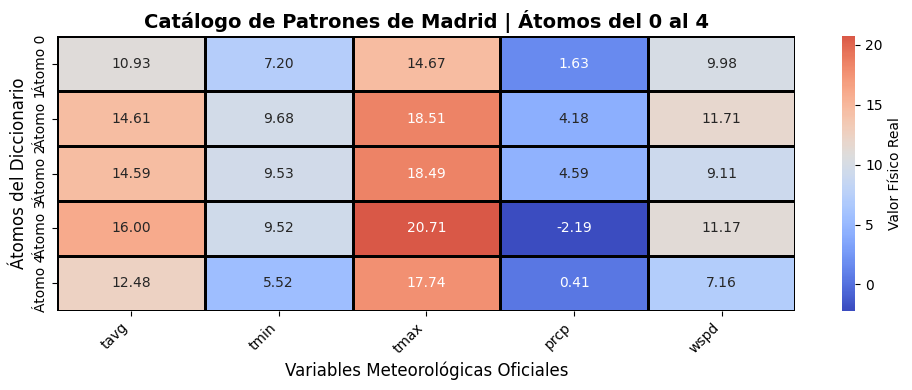

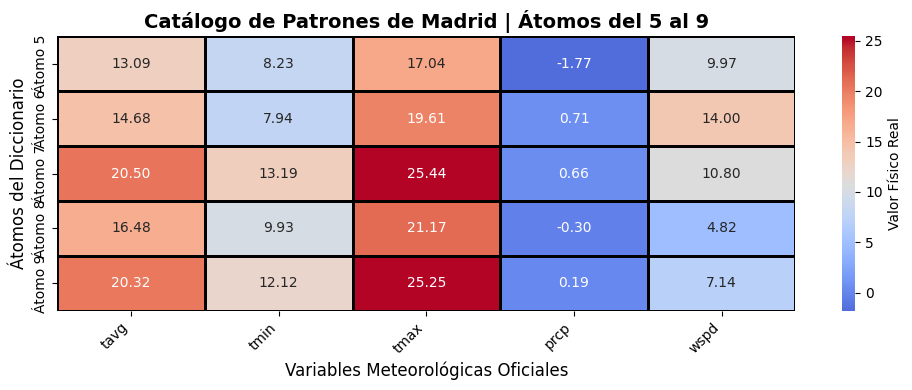

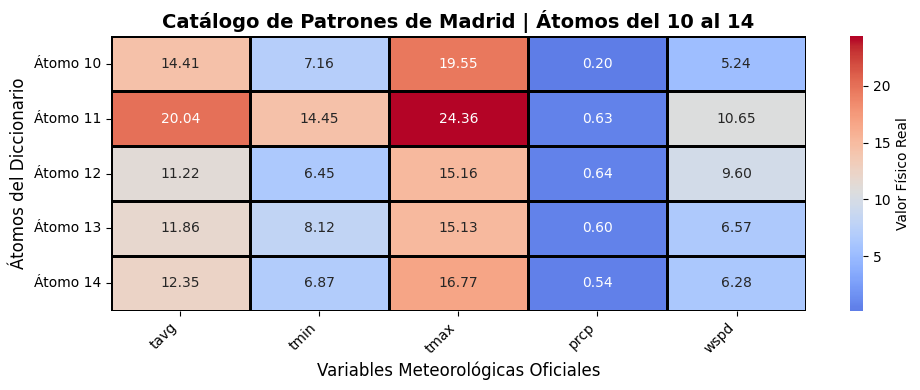

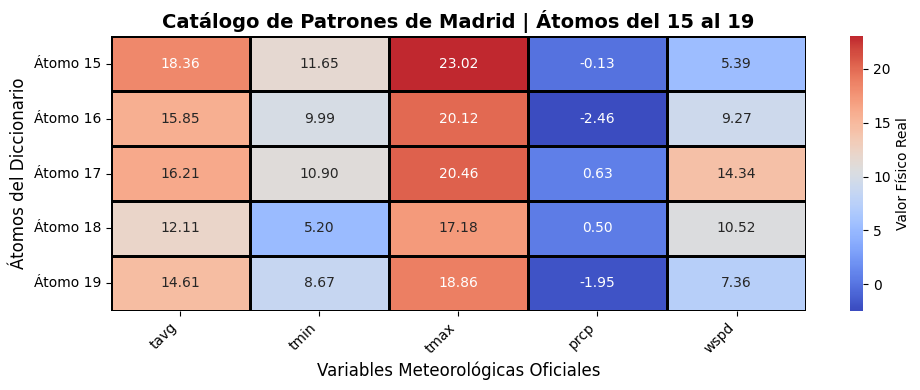

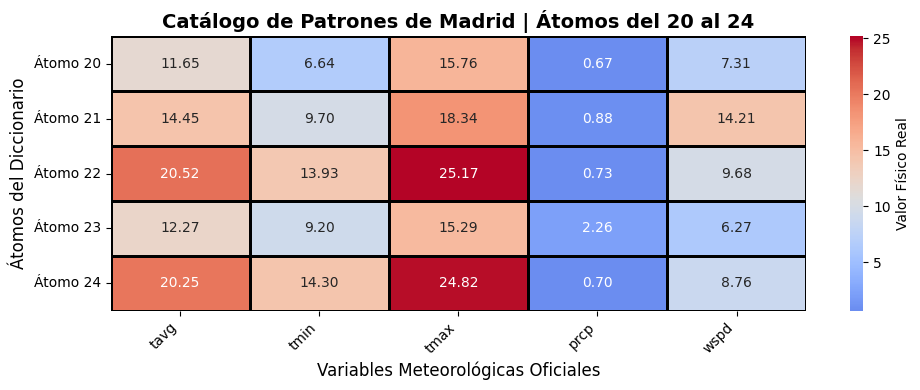

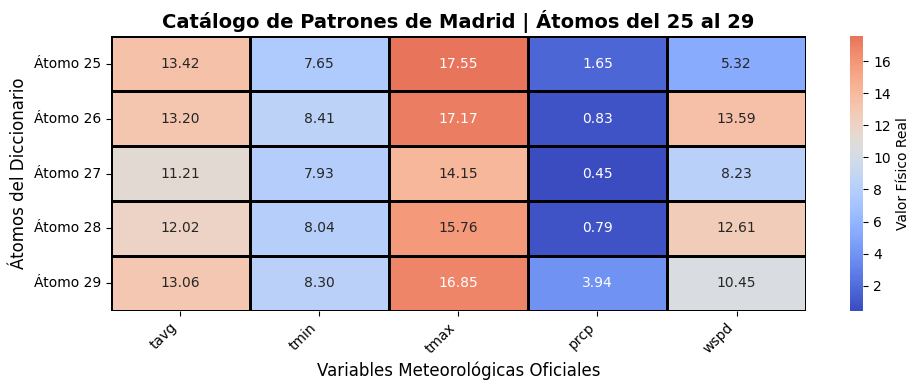

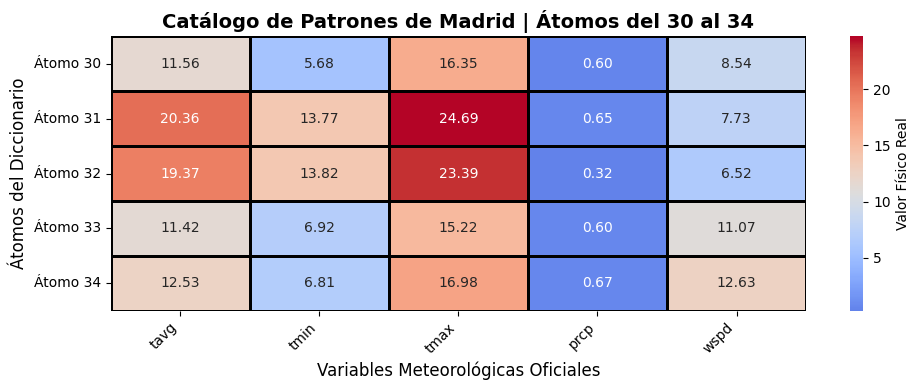

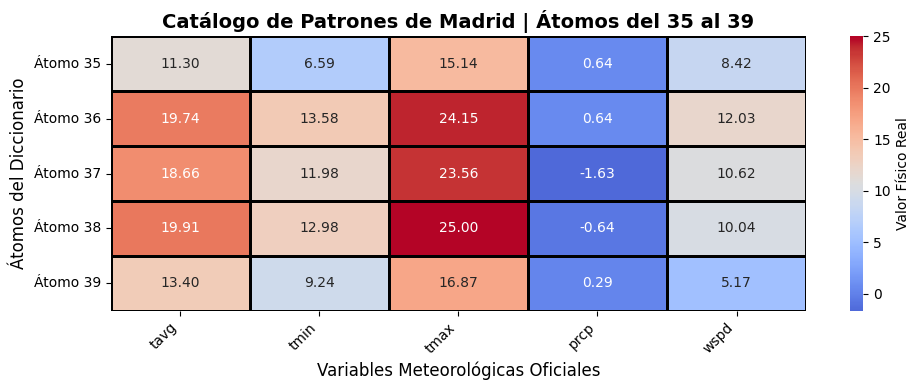

In [ ]:
# Visualizamos los átomos:
print("\nGenerando el catálogo de micro-climas (Grupos de 5)...")

atomos_reales = scaler.inverse_transform(dictionary_atoms)
df_atomos_reales = pd.DataFrame(atomos_reales, columns=nombres_variables)
df_atomos_reales.index = [f"Átomo {i}" for i in range(n_atoms)]

centro_color = df_atomos_reales.mean().mean()

for i in range(0, 40, 5):
    df_chunk = df_atomos_reales.iloc[i : i+5]
    
    plt.figure(figsize=(10, 4))
    
    sns.heatmap(df_chunk, annot=True, fmt=".2f", cmap="coolwarm", center=centro_color,
                linewidths=1, linecolor='black', cbar_kws={'label': 'Valor Físico Real'})
    
    plt.title(f"Catálogo de Patrones de Madrid | Átomos del {i} al {i+4}", fontsize=14, fontweight='bold')
    plt.xlabel("Variables Meteorológicas Oficiales", fontsize=12)
    plt.ylabel("Átomos del Diccionario", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    plt.show()

#### **Veamos información de nuestro diccionario aprendido:**

In [ ]:
sparse_test = dict_learner.transform(X_test_scaled)

X_test_reconstructed = np.dot(sparse_test, dict_learner.components_)

mse_test_exacto = mean_squared_error(X_test_scaled, X_test_reconstructed)

ceros_exactos = np.sum(np.abs(sparse_test) < 1e-5)
esparcidad_test = (ceros_exactos / sparse_test.size) * 100

error_reconstruccion_sum = 0.5 * np.sum((X_test_scaled - X_test_reconstructed) ** 2)
penalizacion_l1 = dict_learner.alpha * np.sum(np.abs(sparse_test))
error_sparse_coding = error_reconstruccion_sum + penalizacion_l1

print("\n" + "="*60)
print(" RESULTADOS EXACTOS SOBRE 3 DÉCADAS")
print("="*60)
print(f" Tiempo de entrenamiento CPU:           {tiempo_ejecucion:.2f} segundos")
print(f" MSE Exacto en la última década (Test): {mse_test_exacto:.4f}")
print(f" Error de Sparse Coding (Coste Total):  {error_sparse_coding:.4f}")
print(f" Esparcidad sostenida:                  {esparcidad_test:.2f}% de ceros")
print("="*60)


 RESULTADOS EXACTOS SOBRE 3 DÉCADAS
 Tiempo de entrenamiento CPU:           55.05 segundos
 MSE Exacto en la última década (Test): 0.0595
 Error de Sparse Coding (Coste Total):  3479.0746
 Esparcidad sostenida:                  94.06% de ceros


### **PARTE DE *TEST* DEL DATASET: REAL vs. RECONSTRUÍDA**

Generando gráficas individuales para las 5 variables físicas...


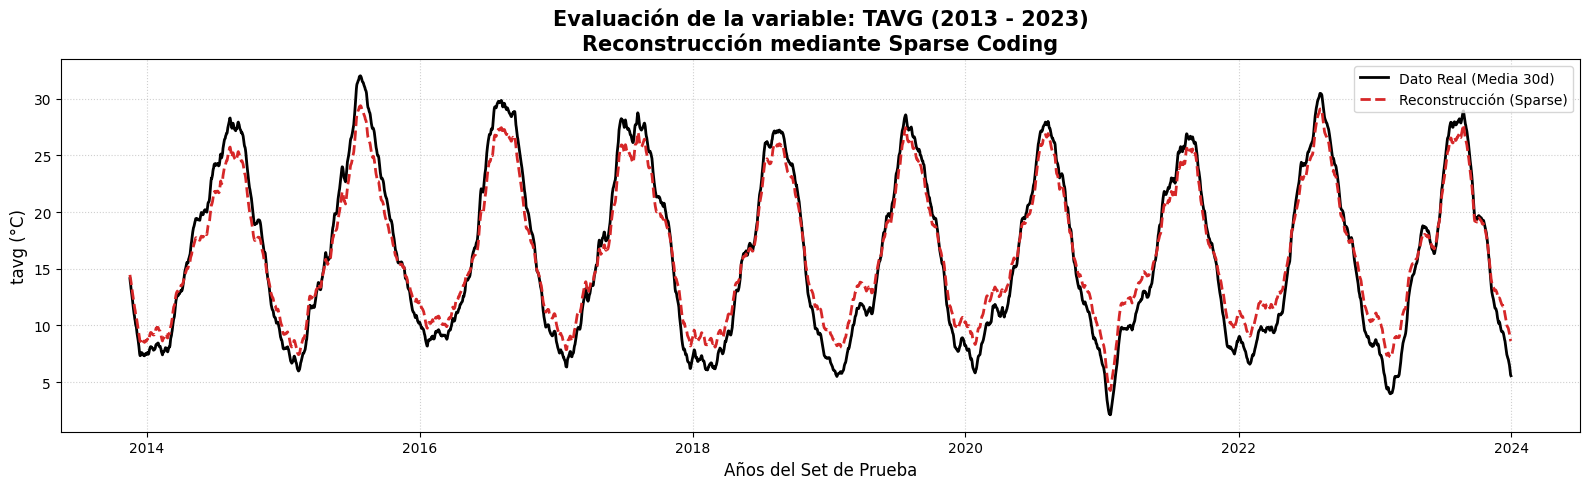

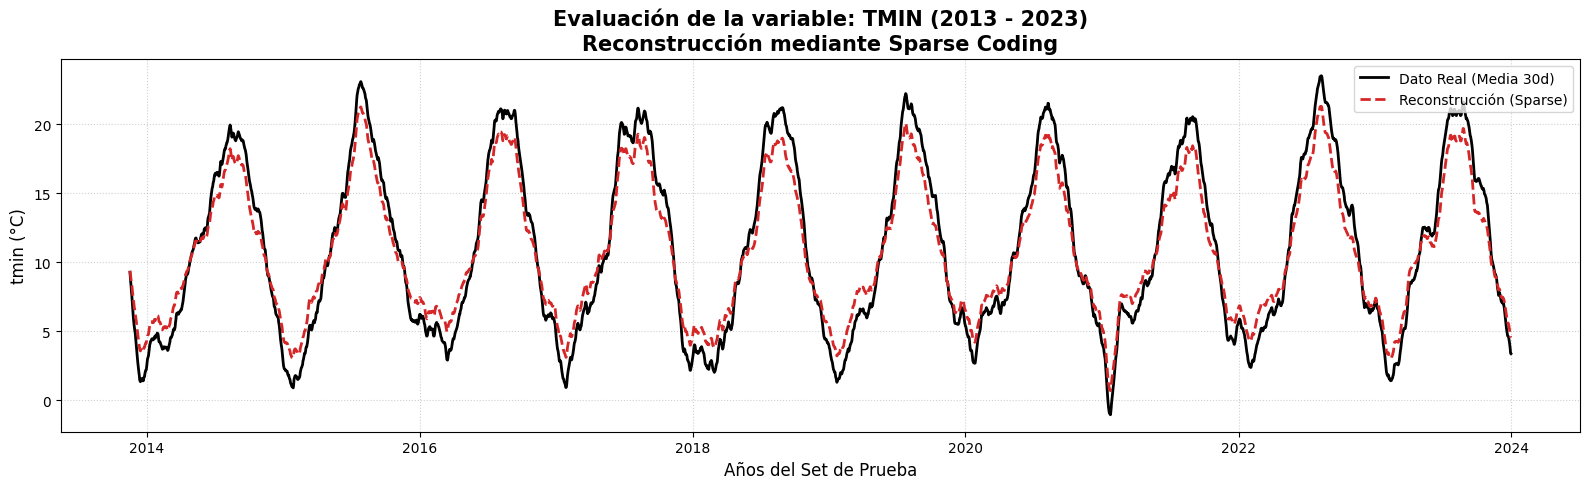

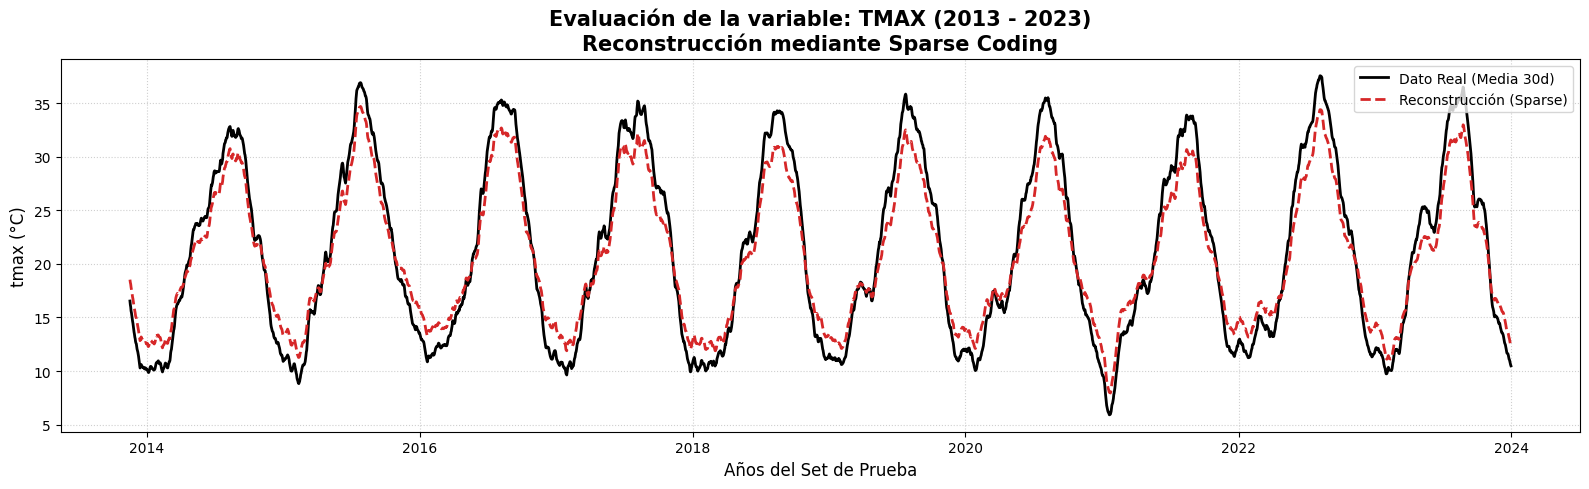

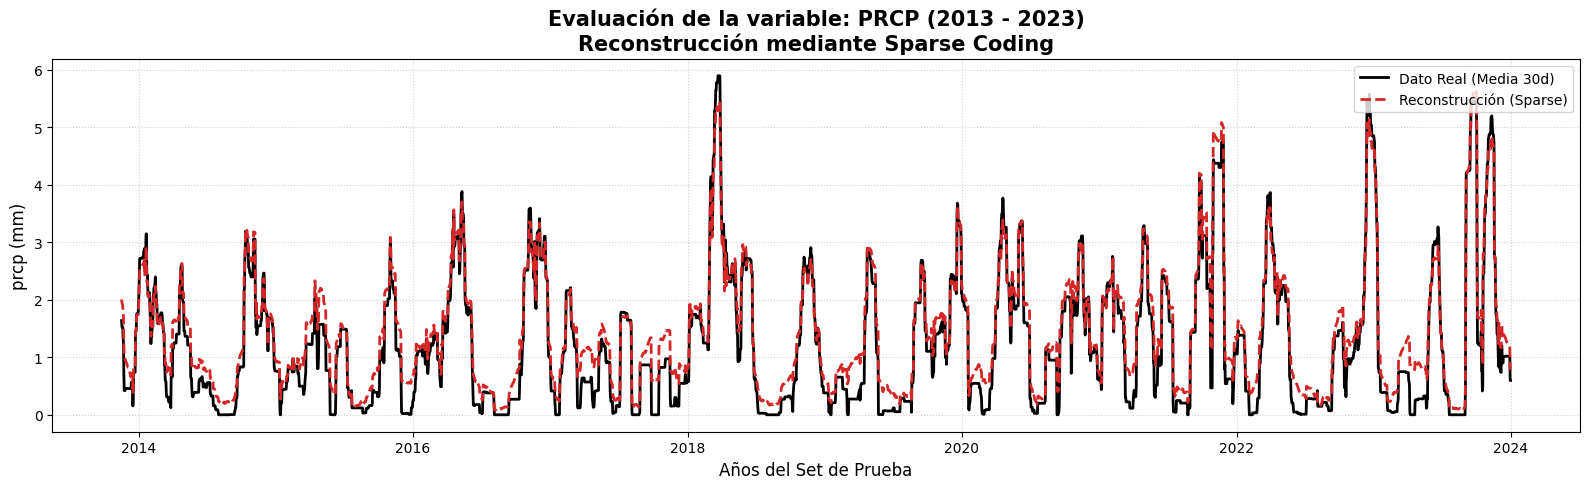

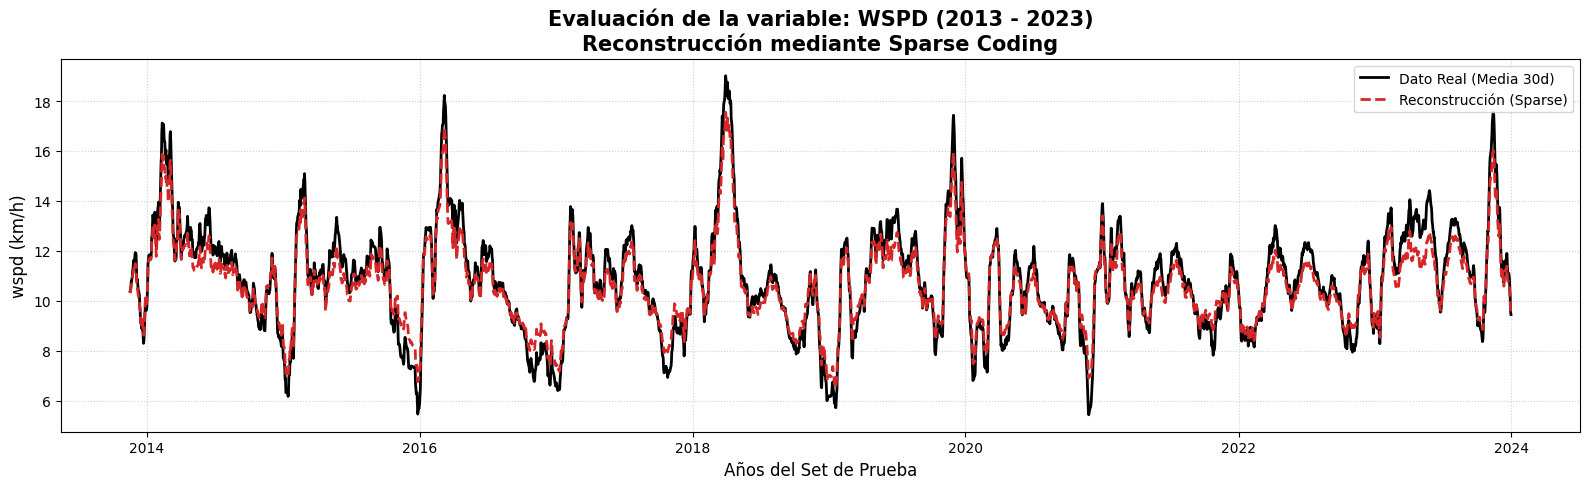

In [ ]:
print("Generando gráficas individuales para las 5 variables físicas...")

test_real_fisico = scaler.inverse_transform(X_test_scaled)
test_recon_fisico = scaler.inverse_transform(X_test_reconstructed)

fechas_test = X_test_raw.index
año_inicio = fechas_test.year.min()
año_fin = fechas_test.year.max()

unidades = {'tavg': '°C', 'tmin': '°C', 'tmax': '°C', 'prcp': 'mm', 'wspd': 'km/h'}

for i, variable in enumerate(nombres_variables):
    
    serie_real = pd.Series(test_real_fisico[:, i], index=fechas_test)
    serie_recon = pd.Series(test_recon_fisico[:, i], index=fechas_test)
    
    real_suavizado = serie_real.rolling(window=30).mean()
    recon_suavizado = serie_recon.rolling(window=30).mean()
    
    plt.figure(figsize=(16, 5))
    
    plt.plot(real_suavizado.index, real_suavizado, color='black', label='Dato Real (Media 30d)', linewidth=2)
    plt.plot(recon_suavizado.index, recon_suavizado, color='tab:red', label='Reconstrucción (Sparse)', linestyle='--', linewidth=2)
    
    unidad = unidades.get(variable, 'Valor')
    plt.title(f'Evaluación de la variable: {variable.upper()} ({año_inicio} - {año_fin})\nReconstrucción mediante Sparse Coding', fontsize=15, fontweight='bold')
    plt.ylabel(f'{variable} ({unidad})', fontsize=12)
    plt.xlabel('Años del Set de Prueba', fontsize=12)
    plt.legend(loc="upper right")
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.tight_layout()
    
    plt.show()

### **Número de átomos idóneo para nuestro alpha=0.5**

Hemos hecho el experimento con 40 átomos por elegir un número, pero revisemos ahora entre varios diccionarios, cual es el mejor.

Iniciando experimento masivo: evaluando 17 configuraciones...
Modelos procesados:  35/140 átomos -> MSE: 0.0602 | Tiempo: 27.55s
Modelos procesados:  70/140 átomos -> MSE: 0.0566 | Tiempo: 81.41s
Modelos procesados: 105/140 átomos -> MSE: 0.0553 | Tiempo: 117.94s
Modelos procesados: 140/140 átomos -> MSE: 0.0544 | Tiempo: 168.34s

Gráficas y tabla de datos...


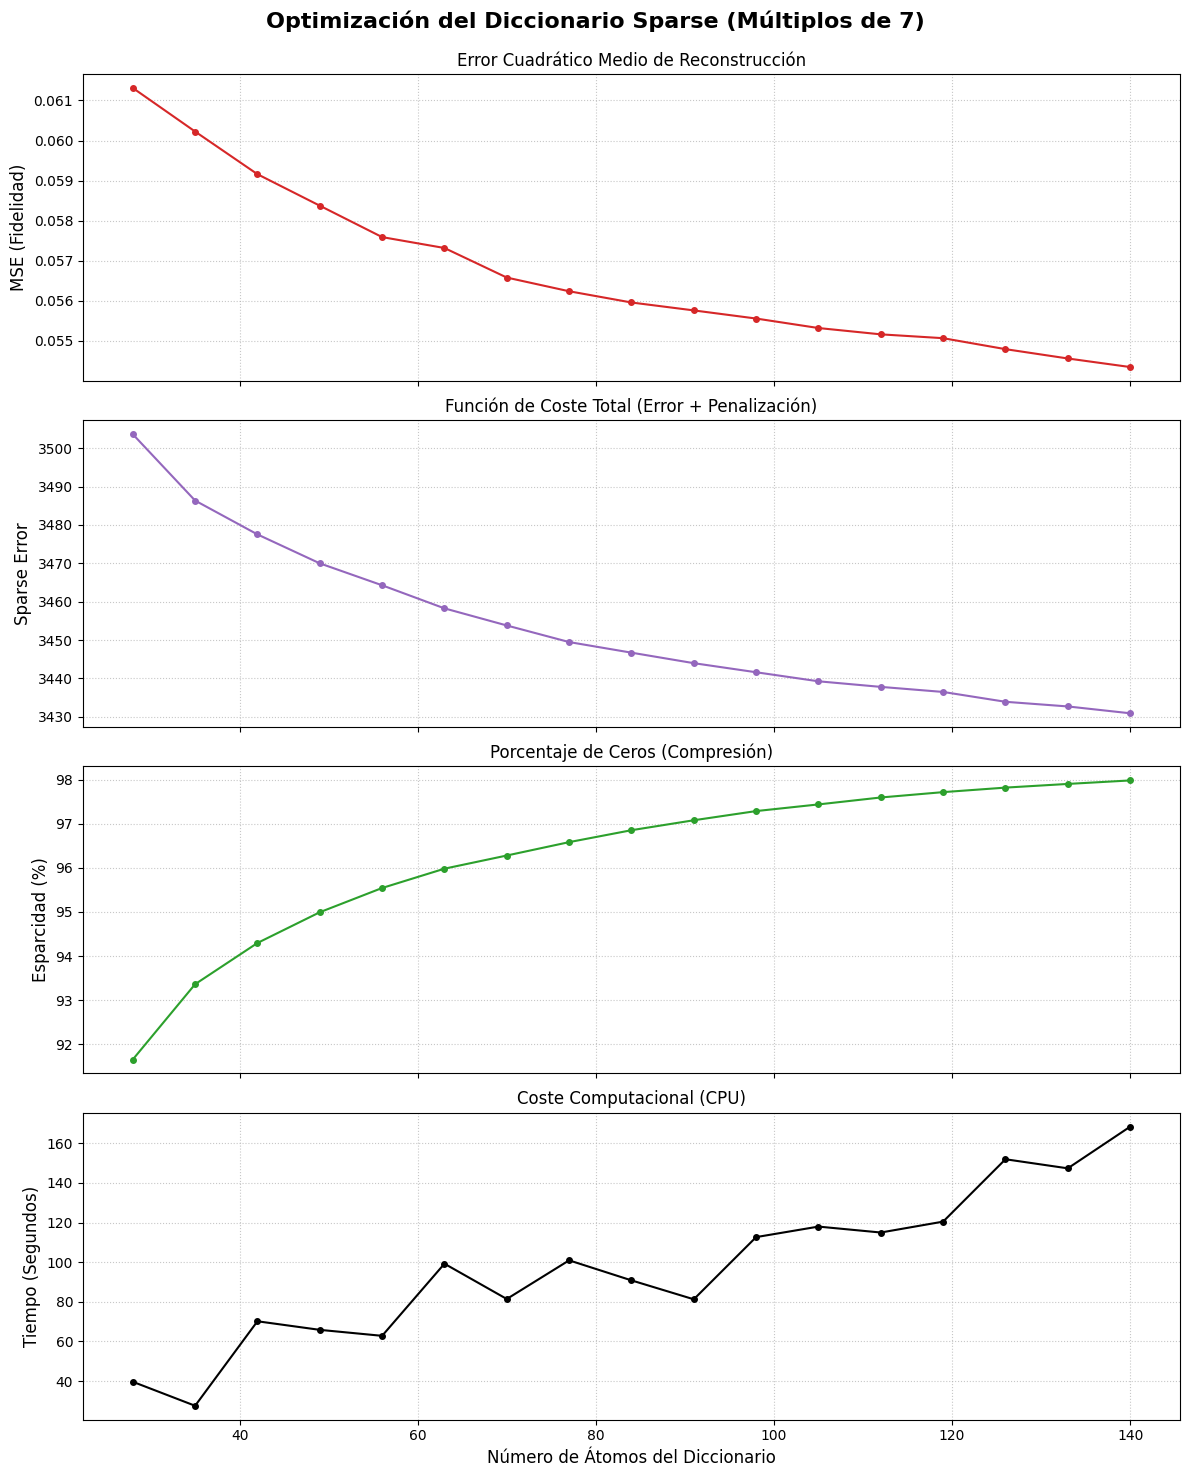


 DATOS NUMÉRICOS EXACTOS
 Atomos      MSE  Sparse_Error  Esparcidad_%  Tiempo_s
     28 0.061311     3503.6815         91.65     39.65
     35 0.060224     3486.3708         93.36     27.55
     42 0.059160     3477.5438         94.30     70.17
     49 0.058375     3469.9976         94.99     65.85
     56 0.057591     3464.2745         95.54     62.83
     63 0.057319     3458.2565         95.98     99.21
     70 0.056582     3453.7908         96.28     81.41
     77 0.056240     3449.4655         96.58    100.91
     84 0.055960     3446.6988         96.85     90.81
     91 0.055763     3443.9602         97.08     81.26
     98 0.055560     3441.5902         97.29    112.63
    105 0.055323     3439.2316         97.44    117.94
    112 0.055165     3437.7743         97.59    114.95
    119 0.055070     3436.4536         97.72    120.44
    126 0.054796     3433.8869         97.82    151.91
    133 0.054564     3432.6730         97.90    147.32
    140 0.054350     3430.8892         

In [ ]:
lista_atomos = [7 * i for i in range(4, 21)]

resultados_mse = []
resultados_sparse_error = []
resultados_esparcidad = []
resultados_tiempo = []

alpha_fijo = 0.5  

print(f"Iniciando experimento masivo: evaluando {len(lista_atomos)} configuraciones...")

for n in lista_atomos:
    inicio_tiempo = time.time()
    
    dict_learner = DictionaryLearning(
        n_components=n, 
        alpha=alpha_fijo, 
        transform_algorithm='lasso_lars', 
        random_state=42, 
        max_iter=500, 
        n_jobs=-1  
    )
    
    dict_learner.fit(X_train_scaled)
    
    sparse_test = dict_learner.transform(X_test_scaled)
    recon_test = np.dot(sparse_test, dict_learner.components_)
    
    tiempo_ejec = time.time() - inicio_tiempo
    
    mse_actual = mean_squared_error(X_test_scaled, recon_test)
    
    ceros = np.sum(np.abs(sparse_test) < 1e-5)
    esparcidad_actual = (ceros / sparse_test.size) * 100
    
    error_recon_sum = 0.5 * np.sum((X_test_scaled - recon_test) ** 2)
    penalizacion_l1 = alpha_fijo * np.sum(np.abs(sparse_test))
    sparse_error_actual = error_recon_sum + penalizacion_l1
    
    resultados_mse.append(mse_actual)
    resultados_sparse_error.append(sparse_error_actual)
    resultados_esparcidad.append(esparcidad_actual)
    resultados_tiempo.append(tiempo_ejec)
    
    print(f"Modelos procesados: {n:3d}/140 átomos -> MSE: {mse_actual:.4f} | Tiempo: {tiempo_ejec:.2f}s")

print("\nGráficas y tabla de datos...")

fig, axs = plt.subplots(4, 1, figsize=(12, 16), sharex=True)
fig.suptitle('Optimización del Diccionario Sparse (Múltiplos de 7)', fontsize=16, fontweight='bold', y=0.92)

axs[0].plot(lista_atomos, resultados_mse, color='tab:red', marker='o', markersize=4, linestyle='-')
axs[0].set_ylabel('MSE (Fidelidad)', fontsize=12)
axs[0].set_title('Error Cuadrático Medio de Reconstrucción', fontsize=12)
axs[0].grid(True, linestyle=':', alpha=0.7)

axs[1].plot(lista_atomos, resultados_sparse_error, color='tab:purple', marker='o', markersize=4, linestyle='-')
axs[1].set_ylabel('Sparse Error', fontsize=12)
axs[1].set_title('Función de Coste Total (Error + Penalización)', fontsize=12)
axs[1].grid(True, linestyle=':', alpha=0.7)

axs[2].plot(lista_atomos, resultados_esparcidad, color='tab:green', marker='o', markersize=4, linestyle='-')
axs[2].set_ylabel('Esparcidad (%)', fontsize=12)
axs[2].set_title('Porcentaje de Ceros (Compresión)', fontsize=12)
axs[2].grid(True, linestyle=':', alpha=0.7)

axs[3].plot(lista_atomos, resultados_tiempo, color='black', marker='o', markersize=4, linestyle='-')
axs[3].set_ylabel('Tiempo (Segundos)', fontsize=12)
axs[3].set_title('Coste Computacional (CPU)', fontsize=12)
axs[3].set_xlabel('Número de Átomos del Diccionario', fontsize=12)
axs[3].grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
fig.subplots_adjust(top=0.88)
plt.show()

df_resultados = pd.DataFrame({
    'Atomos': lista_atomos,
    'MSE': np.round(resultados_mse, 6),
    'Sparse_Error': np.round(resultados_sparse_error, 4),
    'Esparcidad_%': np.round(resultados_esparcidad, 2),
    'Tiempo_s': np.round(resultados_tiempo, 2)
})

print("\n" + "="*60)
print(" DATOS NUMÉRICOS EXACTOS")
print("="*60)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(df_resultados.to_string(index=False))
print("="*60)

Observando las gráficas, podemos deducir que el número de átomos óptimo para alpha=0.5 son **59 átomos**.

### **Identificación de patrones climatológicos.**

Veamos el otro uso del Sparse Coding. En vez de querer reconstruir los átomos, lo que haremos será identificar patrones climatologicos. Queremos entrenar un modelo con **16 átomos** que sea capaz de captar los datos esenciales del clima. Es decir, queremos identificar las estaciones usando los átomos.

Para hacerlo, anteriormente hemos variado el número de átomos para un alpha fijo para encontrar el óptimo. Pues ahora usaremos una herramienta de diagnóstico conocida como **L-Curve**. Esto lo que hace es buscar el punto de compromiso óptimo (sweet spot), es decir, buscar un alpha que equilibre:
- Fidelidad (bajo error): que el modelo sea capaz de reconstruir el clima de madrid casi sin errores.
- Simplicidad (alta esparcidad): que el modelo use el menor número posible de átomos para explicar cada día.

Lo que sabemos es que:
- alpha bajo: el modelo es más restrictivo a la hora de elegir el número de átomos que usa para la reconstrucción. Por lo que el MSE es menor, y la esparcidad también.
- alpha alto: el modelo es menos restrictivo, por lo que intenta recrear el clima usando el menor número de átomos. Esto hace que el MSE sea mayor y la esparcidad también, ya que la mayoría de átomos ni los usa.

Calculando Curva L para 16 átomos.
Alpha 0.10  | MSE Exacto: 0.0044 | Norma L1: 7852.25 | Esparcidad: 75.70%
Alpha 0.25  | MSE Exacto: 0.0207 | Norma L1: 6977.97 | Esparcidad: 81.93%
Alpha 0.50  | MSE Exacto: 0.0651 | Norma L1: 5853.56 | Esparcidad: 86.60%
Alpha 0.75  | MSE Exacto: 0.1289 | Norma L1: 4898.89 | Esparcidad: 89.37%
Alpha 1.00  | MSE Exacto: 0.2097 | Norma L1: 4031.09 | Esparcidad: 91.88%
Alpha 1.25  | MSE Exacto: 0.3012 | Norma L1: 3273.34 | Esparcidad: 93.36%
Alpha 1.50  | MSE Exacto: 0.3979 | Norma L1: 2616.15 | Esparcidad: 94.54%
Alpha 2.00  | MSE Exacto: 0.5885 | Norma L1: 1591.90 | Esparcidad: 96.58%
Alpha 3.00  | MSE Exacto: 0.8633 | Norma L1:  530.20 | Esparcidad: 98.93%
Alpha 5.00  | MSE Exacto: 1.0139 | Norma L1:  144.30 | Esparcidad: 99.88%
Alpha 10.00 | MSE Exacto: 1.0948 | Norma L1:   31.76 | Esparcidad: 99.98%

Tiempo total de la prueba: 143.77 segundos.


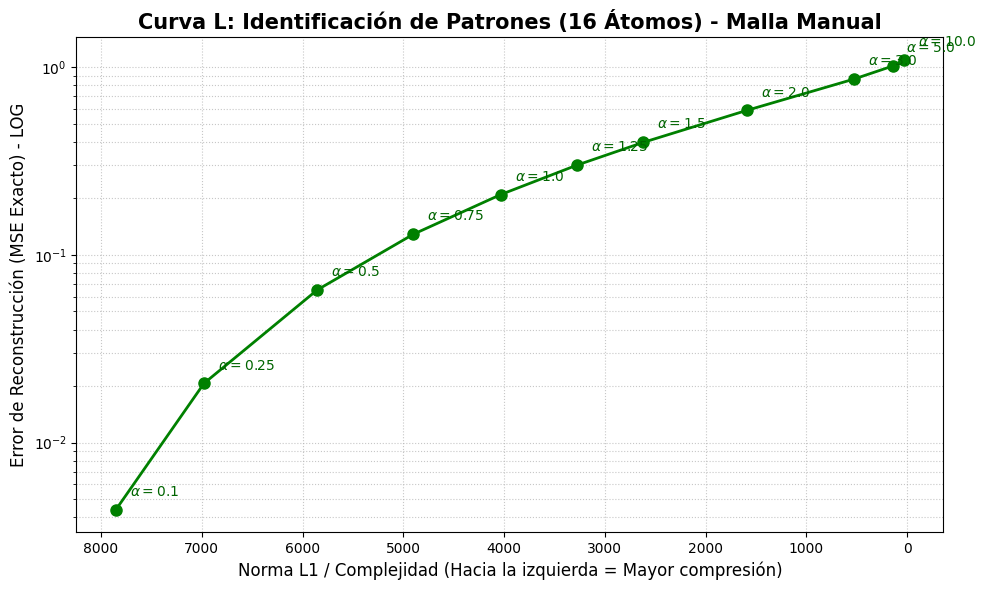

In [ ]:
alphas_especificos = [0.1, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 2.0, 3.0, 5.0, 10.0]

n_atoms_especiales = 16

errores_reconstruccion_16 = []
penalizaciones_esparcidad_16 = []

print(f"Calculando Curva L para {n_atoms_especiales} átomos.")

start_total = time.time()

datos_entrada = X_train_scaled 

for alpha_val in alphas_especificos:
    
    dict_learner_16 = DictionaryLearning(
        n_components=n_atoms_especiales, 
        alpha=alpha_val, 
        transform_algorithm='lasso_lars', 
        random_state=42, 
        n_jobs=-1,
        max_iter=500 
    )
    
    U = dict_learner_16.fit_transform(datos_entrada)
    V = dict_learner_16.components_
    
    X_reconstruido = np.dot(U, V)
    
    mse_exacto = mean_squared_error(datos_entrada, X_reconstruido)
    
    l1_norm = np.sum(np.abs(U))
    
    ceros = np.sum(np.abs(U) < 1e-5)
    esparcidad_porcentaje = (ceros / U.size) * 100
    
    errores_reconstruccion_16.append(mse_exacto)
    penalizaciones_esparcidad_16.append(l1_norm)
    
    print(f"Alpha {alpha_val:<5.2f} | MSE Exacto: {mse_exacto:.4f} | Norma L1: {l1_norm:7.2f} | Esparcidad: {esparcidad_porcentaje:5.2f}%")

print(f"\nTiempo total de la prueba: {time.time() - start_total:.2f} segundos.")

plt.figure(figsize=(10, 6))

plt.plot(penalizaciones_esparcidad_16, errores_reconstruccion_16, 'go-', linewidth=2, markersize=8)

for i, alpha_val in enumerate(alphas_especificos):
    plt.annotate(f'$\\alpha={alpha_val}$', 
                 (penalizaciones_esparcidad_16[i], errores_reconstruccion_16[i]),
                 textcoords="offset points", 
                 xytext=(10, 10), 
                 ha='left',
                 fontsize=10,
                 fontweight='bold',
                 color='darkgreen')

plt.yscale('log')

plt.title('Curva L: Identificación de Patrones (16 Átomos) - Malla Manual', fontsize=15, fontweight='bold')
plt.xlabel('Norma L1 / Complejidad (Hacia la izquierda = Mayor compresión)', fontsize=12)
plt.ylabel('Error de Reconstrucción (MSE Exacto) - LOG', fontsize=12)

plt.gca().invert_xaxis() 

plt.grid(True, which="both", linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

Podemos observar que el punto óptimo es **alpha=1.0**. Veamos por que:

- Con alpha de 1.0, tenemos una esparcidad del 91.88%. Lo que significa que usa en promedio **1.3 átomos activos** (16 x (1-0.9188) = 1.3). Por lo que para reconstruir cada día usa de promedio un átomo. El 0.3 se debe a días más complejos.

- Con alpha de 1.25, la esparcidad sube al 93.36%, que es casi un átomo por día. Pero el MSE aumenta de 0.2097 a 0.3012. Por lo que el error de reconstrucción aumenta un 43%. Por lo que el modelo no capta la realidad de los datos.

- Con alpha de 0.75, la esparcidad cae por debajo del 90%, por lo que pasamos a usar casi 2 átomos completos y concurrentes por día, por lo que las firmas climáticas se pierden.

### **Veamos los 16 átomos que representan los patrones climatológicos.**

Veamos los 16 arquetipos (Alpha=1.0)...


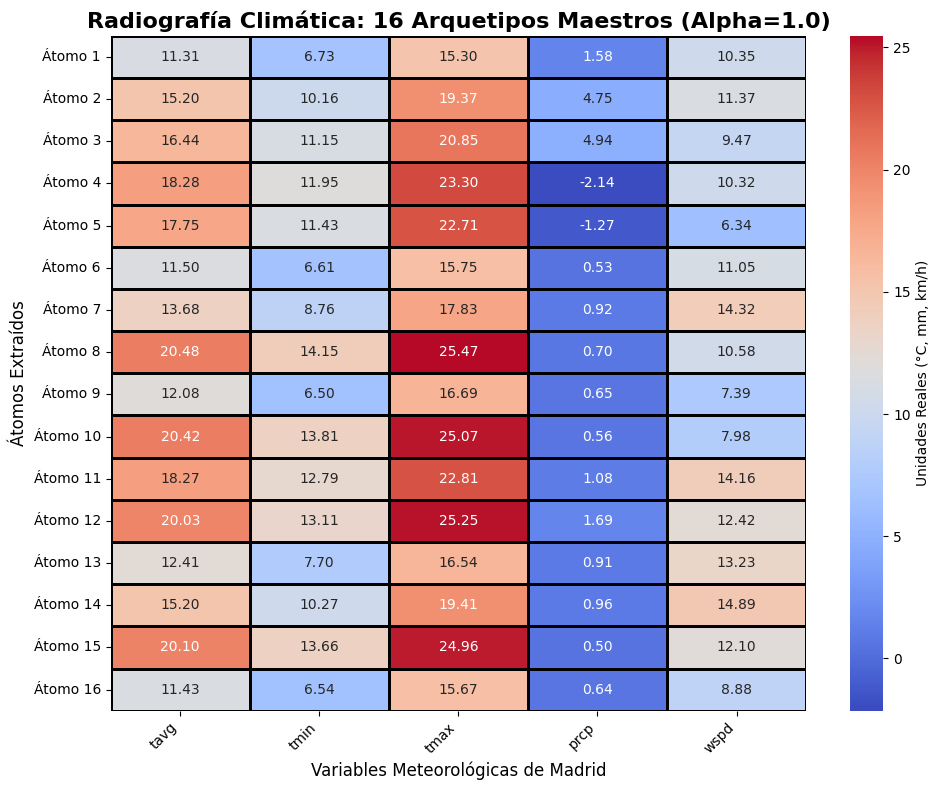


 VALORES EXACTOS DE LOS 16 ÁTOMOS (ALPHA = 1.0)
            tavg    tmin    tmax   prcp    wspd
Átomo 1   11.311   6.729  15.301  1.579  10.351
Átomo 2   15.205  10.158  19.368  4.755  11.375
Átomo 3   16.444  11.148  20.850  4.941   9.469
Átomo 4   18.283  11.947  23.297 -2.137  10.324
Átomo 5   17.746  11.426  22.710 -1.267   6.338
Átomo 6   11.498   6.614  15.754  0.533  11.047
Átomo 7   13.681   8.762  17.829  0.924  14.320
Átomo 8   20.484  14.151  25.475  0.696  10.581
Átomo 9   12.081   6.495  16.694  0.655   7.392
Átomo 10  20.421  13.814  25.074  0.560   7.980
Átomo 11  18.269  12.787  22.807  1.079  14.162
Átomo 12  20.033  13.110  25.254  1.691  12.421
Átomo 13  12.412   7.695  16.537  0.913  13.226
Átomo 14  15.200  10.271  19.405  0.964  14.892
Átomo 15  20.104  13.661  24.965  0.502  12.104
Átomo 16  11.426   6.535  15.667  0.642   8.883


In [ ]:
scaler = StandardScaler()
X_total_scaled = scaler.fit_transform(X_raw)
nombres_variables = X_raw.columns.tolist()

n_atoms_objetivo = 16
alpha_objetivo = 1.0

print(f"Veamos los {n_atoms_objetivo} arquetipos (Alpha={alpha_objetivo})...")

dict_learner_16 = DictionaryLearning(
    n_components=n_atoms_objetivo,
    alpha=alpha_objetivo,
    transform_algorithm='lasso_lars',
    random_state=42,
    max_iter=1000,
    n_jobs=-1
)

dict_learner_16.fit(X_total_scaled)
atomos_escalados = dict_learner_16.components_

atomos_fisicos = scaler.inverse_transform(atomos_escalados)
df_atomos_16 = pd.DataFrame(atomos_fisicos, columns=nombres_variables)
df_atomos_16.index = [f"Átomo {i+1}" for i in range(n_atoms_objetivo)]

plt.figure(figsize=(10, 8))
centro_color = df_atomos_16.mean().mean()

sns.heatmap(
    df_atomos_16, 
    annot=True,          
    fmt=".2f",          
    cmap="coolwarm",     
    center=centro_color,
    linewidths=1, 
    linecolor='black', 
    cbar_kws={'label': 'Unidades Reales (°C, mm, km/h)'}
)

plt.title(f'Radiografía Climática: {n_atoms_objetivo} Arquetipos Maestros (Alpha={alpha_objetivo})', fontsize=16, fontweight='bold')
plt.xlabel('Variables Meteorológicas de Madrid', fontsize=12)
plt.ylabel('Átomos Extraídos', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print(f" VALORES EXACTOS DE LOS {n_atoms_objetivo} ÁTOMOS (ALPHA = {alpha_objetivo})")
print("=" * 60)
print(df_atomos_16.round(3).to_string())
print("=" * 60)

**Motores del Verano:**
- Átomo 8 (verano puro): calor seco y viento moderado.
- Átomo 10 (calor estancado): calor sin aire.
- Átomo 12 (tormenta de verano): calor con lluvia.
- Átomo 15 (calor racheado): Calor con viento más fuerte.

**Borrascas:**
- Átomo 3 (diluvio templado): lluvia intensa con temperaturas suaves.
- Átomo 2 (temporal frío): lluvia intensa con temperaturas bajas.

**Sequía extrema:**
- Átomo 4: dia agradable pero extremadamente seco.
- Átomo 5: temperatura suave, seco y poco viento.

**Invierno puro:**
- Átomo 1 (invierno crudo): frío con lluvia.
- Átomo 6 (invierno estándar): días fríos y secos.
- Átomo 9 (invierno anticiclónico): frío con viento.

**Vendaval:**
- Átomo 14: viento mas violento.

Los átomos 7, 11 y 13 son de transición. Combinan vientos fuertes con temperaturas variables.

### **Días climatológicos extremos.**

Una de las aplicaciones que podemos hacer, usando nuestro átomos aprendidos de los patrones climatológicos, es detectar efectos metereológicos peculiares. Para ello, intentamos reonstruir todo el datatset usando nuestros átomos y filtramos los días con mayor MSE.

In [ ]:
print("Calculando el error de reconstrucción diario...")

activaciones = dict_learner_16.transform(X_total_scaled)
X_reconstruido = np.dot(activaciones, atomos_escalados)

errores_diarios = np.mean((X_total_scaled - X_reconstruido) ** 2, axis=1)

df_anomalias = pd.DataFrame({
    'Fecha': X_raw.index,
    'Error_MSE_Exacto': errores_diarios
})

top_anomalias = df_anomalias.sort_values(by='Error_MSE_Exacto', ascending=False).head(15)

print("\n" + "="*60)
print(" TOP 15 ANOMALÍAS CLIMÁTICAS EN MADRID (1990-2024)")
print("="*60)
top_anomalias['Fecha_Limpia'] = top_anomalias['Fecha'].dt.strftime('%Y-%m-%d')
print(top_anomalias[['Fecha_Limpia', 'Error_MSE_Exacto']].to_string(index=False))
print("="*60)

Calculando el error de reconstrucción diario...

 TOP 15 ANOMALÍAS CLIMÁTICAS EN MADRID (1990-2024)
Fecha_Limpia  Error_MSE_Exacto
  1991-03-24          0.216449
  2014-04-20          0.216172
  2023-09-04          0.214771
  2021-09-24          0.213967
  2014-10-09          0.213353
  2003-09-30          0.212311
  1997-11-05          0.212129
  2021-06-16          0.211826
  2023-10-19          0.211593
  2020-03-02          0.211491
  2023-11-30          0.211468
  2009-01-24          0.211316
  2007-10-02          0.210987
  2017-02-05          0.210982
  2018-03-24          0.210745


- El 24-03-1991, una masa de aire frío invadió la zona centro de España. Un día de primavera con temperatura máxima de 7.8ºC.

- El 04-09-2023 fue la fecha de la Dana, hubo lluvias y tormentas intensas (13.5 L/m2).

### **Cambio climático.**

In [ ]:
top_atomos_calor = df_atomos_16.nlargest(4, 'tmax').index.tolist()
print(f"Detectados los Átomos de Calor Extremo: {top_atomos_calor}\n")

print("Calculando activaciones de todos los días históricos a máxima potencia...")
activaciones_reales = dict_learner_16.transform(X_total_scaled)

df_act = pd.DataFrame(activaciones_reales, columns=df_atomos_16.index)
df_act['fecha'] = X_raw.index
df_act['año'] = df_act['fecha'].dt.year
df_act['tmax_real'] = X_raw['tmax'].values

idx_dias_pico = df_act.groupby('año')['tmax_real'].idxmax()
df_picos_historico = df_act.loc[idx_dias_pico].copy()

columnas_finales = ['fecha', 'tmax_real'] + top_atomos_calor
tabla_comparativa = df_picos_historico[columnas_finales].sort_values('fecha')

print("="*80)
print(" RADIOGRAFÍA DEL DÍA MÁS CALUROSO DE CADA AÑO (1990 - 2024)")
print("="*80)
print(tabla_comparativa.round(4).to_string(index=False))
print("="*80)

Detectados los Átomos de Calor Extremo: ['Átomo 8', 'Átomo 12', 'Átomo 10', 'Átomo 15']

Calculando activaciones de todos los días históricos a máxima potencia...
 RADIOGRAFÍA DEL DÍA MÁS CALUROSO DE CADA AÑO (1990 - 2024)
     fecha  tmax_real  Átomo 8  Átomo 12  Átomo 10  Átomo 15
1990-07-20       36.9   0.0000    0.0000    0.0000    0.0000
1991-08-16       39.3   0.0000    0.0000    0.0000    0.0000
1992-07-28       37.8   0.0000    0.0000    0.0000    0.0000
1993-08-20       39.9   0.0000    0.0000    0.0000    0.0000
1994-06-30       37.9   0.0000    0.0000    0.0000    0.0000
1995-07-24       39.4   0.0000    0.0000    0.0000    0.0000
1996-07-20       36.9   0.0000    0.0000    0.1591    0.0000
1997-08-02       36.4   0.0000    0.0000    0.5319    0.0000
1998-07-24       36.4   0.0000    0.0000    2.1302    0.0000
1999-07-22       37.2   0.9638    0.0000    0.0000    1.2403
2000-07-31       36.3   0.0000    0.0000    0.4178    0.0000
2001-06-22       36.3   0.0000    0.0000    0

El átomo 8 es el átomo con mayor temperatura, la tendencia de los últimos años es que se active más.